In [1]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("front.jl")

[ Info: Oceananigans will use 4 threads


front_width (generic function with 1 method)

In [4]:
foldername = "../../scratch/turbulence-at-many-fronts/StrainM-C20"

DFM = joinpath(foldername, "DFM.jld2")
RI = joinpath(foldername, "RI.jld2")
PV = joinpath(foldername, "PV.jld2")
TKE = joinpath(foldername, "TKE.jld2")
SLICES = joinpath(foldername, "SLICES.jld2")

iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
inds = center_indices(DFM);

# Time
We can account for different kinematics with the strain by using the non-dimensional accumulated strain as the time coordinate.
$$
s(t) = \int_{0}^t \alpha (t_1) \text{d}t_1.
$$
A passive tracer $c$ would then obey
$$
c(x, s) = c(xe^{s}, 0),
$$
regardless of details of the time-dependent strain rate $\alpha$.

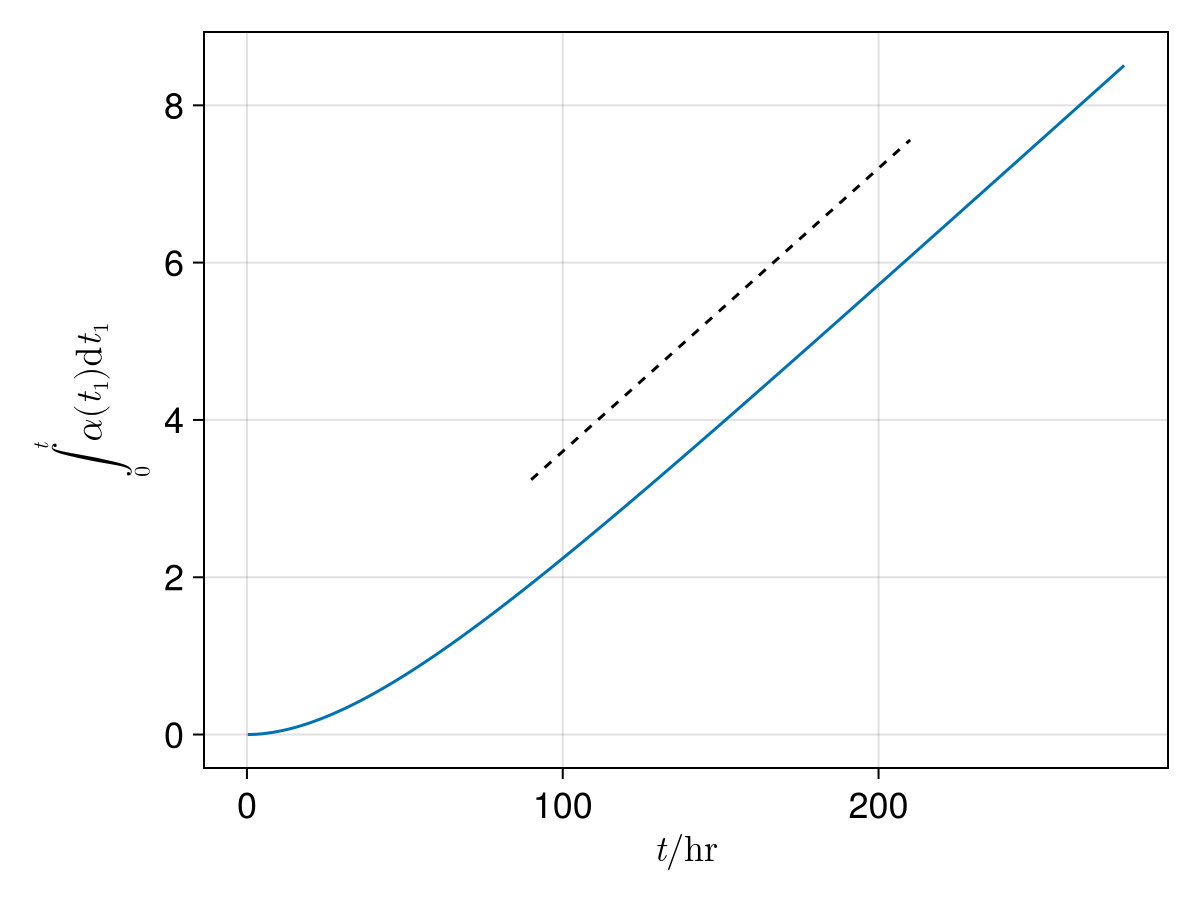

In [5]:
# Time coordinate is the cumulative deformation
∫αdt = normalized_time(DFM)
fig = Figure(; fontsize=18)
ax = Axis(fig[1, 1],
    xlabel = L"t / \text{hr}", 
    ylabel = L"\int_{0}^t\alpha(t_1) \text{d} t_1"
) 
lines!(ax, times ./ 3600, ∫αdt)
lines!(ax, range(90, 210, 100), sp.α .* range(90, 210, 100) .* 3600; color=:black, linestyle=:dash)
fig

# Front definition
Both the near-surface front and the depth-averaged front
$$
b_\text{surface}(x, t) = \frac{1}{0.05H}\int_{-0.15H}^{-0.1H} b(x, z, t) ~\text{d}z,
$$
$$
b_\text{center}(x, t) = \frac{1}{0.6H}\int_{-0.85H}^{-0.15H} b(x, z, t) ~\text{d}z.
$$
Below is a plot comparing them. Red contours are the buoyancy levels used to define the frontal width, 
$$
\frac{1}{L_x}\int_{-L_x / 2}^{L_x / 2} b_i(x, t)\,\text{d}x \pm \Delta b / 6.
$$
This needs to be a bit tight to cope with the high-cooling simulations...

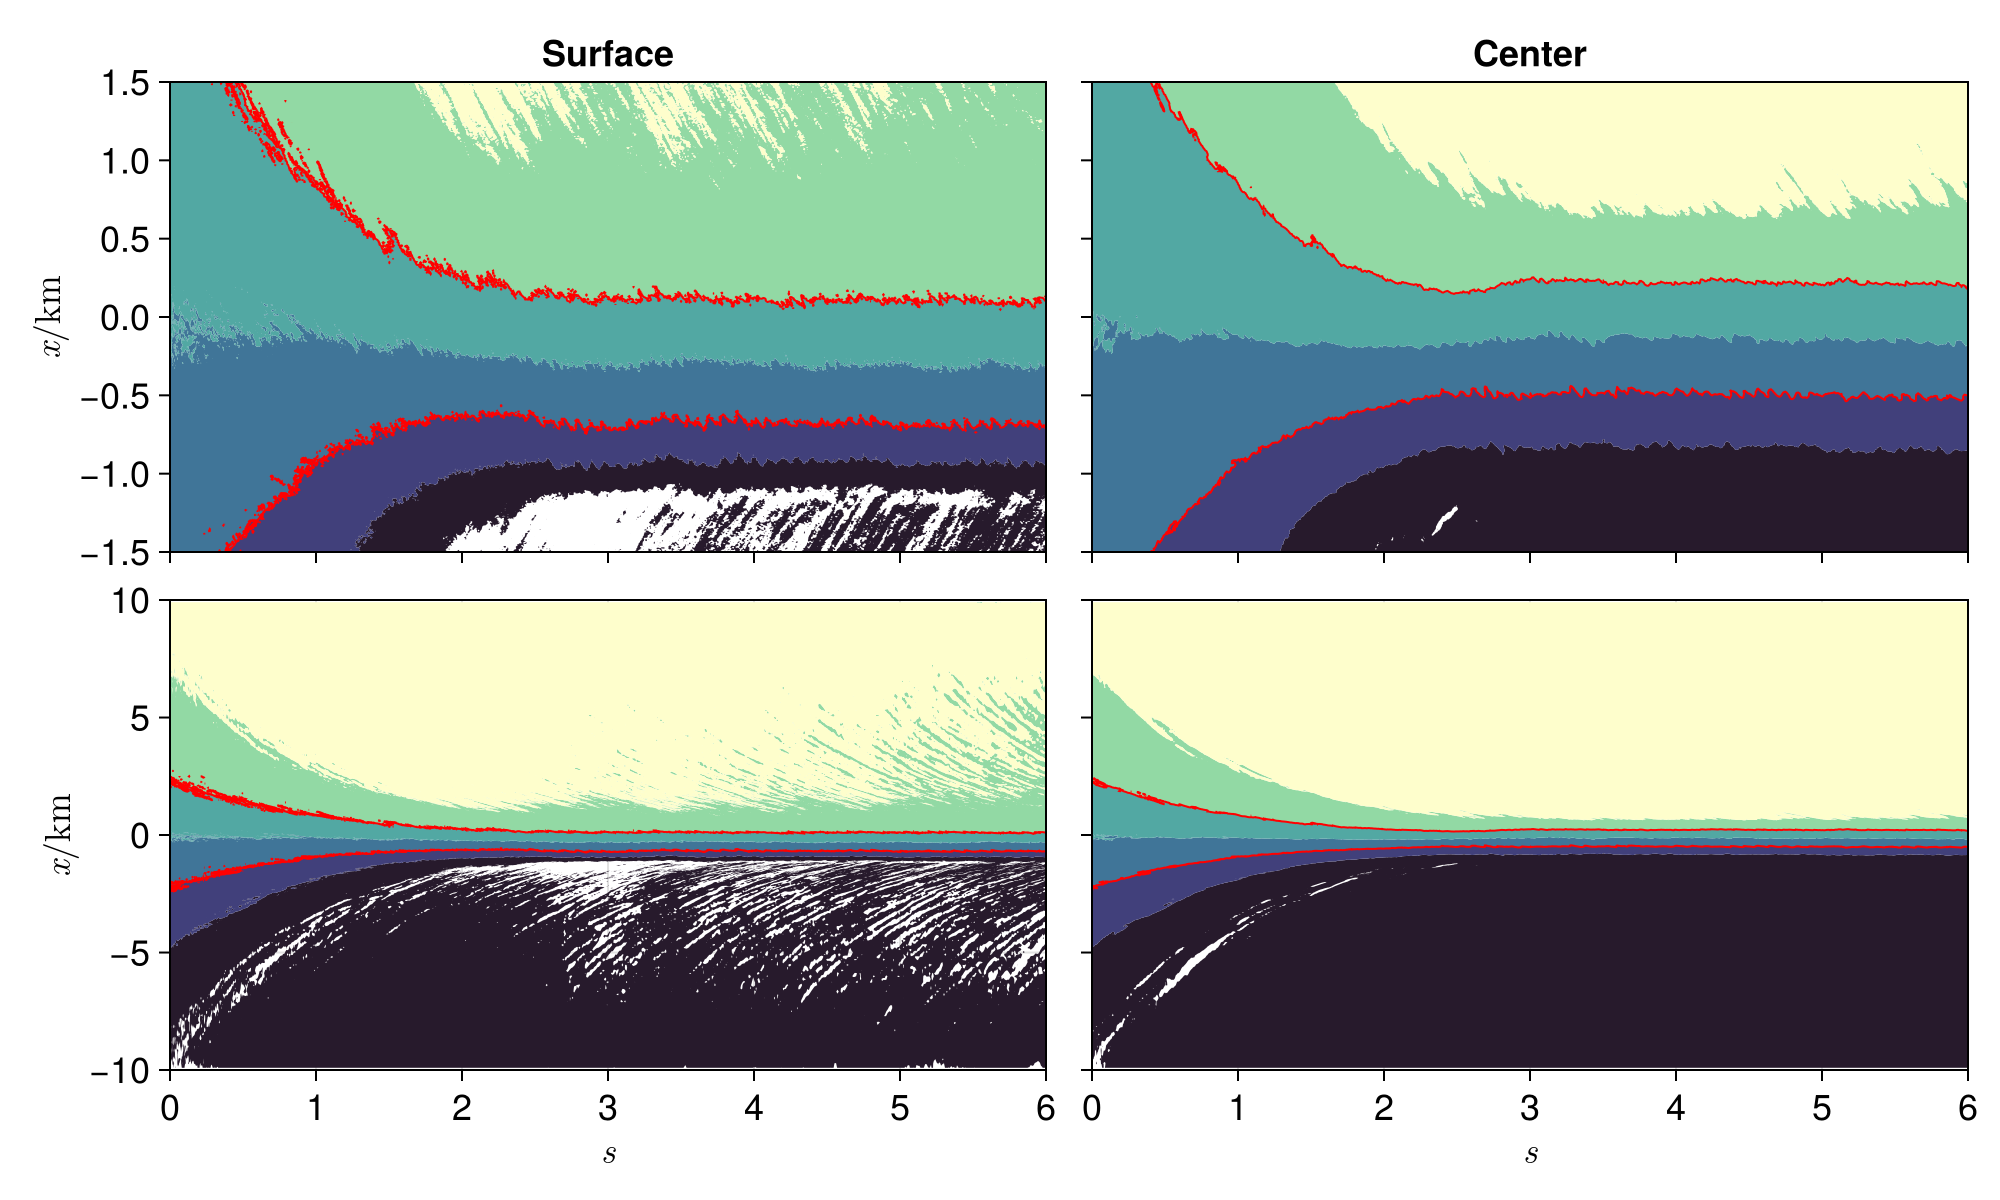

In [36]:
levels = (-sp.Δb/2):(sp.Δb / 6):(sp.Δb/2)
colormap = reverse(to_colormap(:deep))

b_surface = avg_buoyancy(DFM, -15, -10)
b_center = avg_buoyancy(DFM, -85, -15)

bl = -sp.Δb / 6
br = sp.Δb / 6

fig = Figure(; 
    fontsize = 18,
    size = (1000, 600)
)

ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
    title = "Surface"
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [br], color = :red)
hidexdecorations!(ax; ticks = false)

ax = Axis(fig[1, 2];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
    title = "Center"
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [br], color = :red)
hidexdecorations!(ax; ticks = false)
hideydecorations!(ax; ticks = false)


ax = Axis(fig[2, 1];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lx / 2000, sp.Lx / 2000),
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [br], color = :red)

ax = Axis(fig[2, 2];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lx / 2000, sp.Lx / 2000),
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [br], color = :red)
hideydecorations!(ax; ticks = false)

fig

In [37]:
bl = -sp.Δb / 6
br = sp.Δb / 6

ilr_surface, xlr_surface, ℓ_surface = front_width(DFM, b_surface .- mean(b_surface; dims=2), bl, br)
ilr_center, xlr_center, ℓ_center = front_width(DFM, b_center .- mean(b_center; dims=2), bl, br)
#ilr_mixed, xlr_mixed, ℓ_mixed = front_width(DFM, b_mixed .- mean(b_mixed; dims=2), bl, br);

([78.25079568773562 950.227968992152; 78.28703699801238 950.2342640748291; … ; 364.3231328000858 560.9038757220138; 364.4883810179944 559.6263458840075], [-2180.539958046165 2301.7823828136497; -2179.3613799741534 2302.017070019932; … ; -578.815887499665 189.0776395391164; -578.1703866484594 184.0872886094041], [4482.322340859815, 4481.378449994085, 4479.774071421082, 4495.696191695915, 4458.9413635013625, 4459.044112900698, 4450.836772367762, 4443.169601444169, 4427.005701106773, 4417.924090334219  …  711.221462499087, 715.561470220688, 725.8221388703774, 730.8166812753997, 741.9541550619847, 749.5837290094397, 764.4448284720406, 761.143853871342, 767.8935270387814, 762.2576752578635])

The following plot is the various measures of the frontal width $\ell$ over time. Length scales which evolve passively with the background flow have gradient equal to the black, dashed line. The red, dash-dot line is the deformation radius of the reference front used to define the initial conditions.

The evolution follows the passive strain flow evolution initially, but is arrested at the deformation radius.

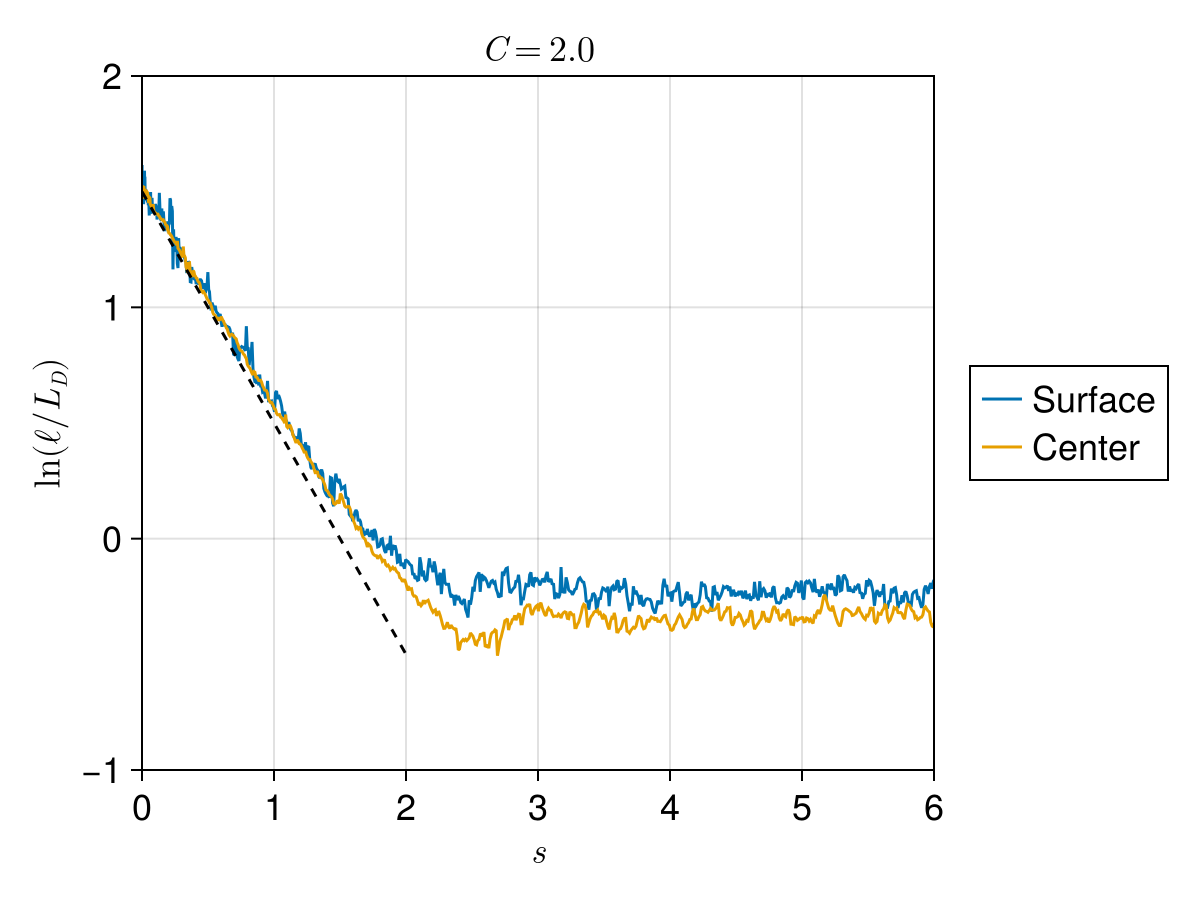

In [41]:
fig = Figure(; fontsize=18)

C = @sprintf "%02.1f" sp.Ek

ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\ell / L_D)",
    limits = (0, 6, -1, 2),
    title = L"C = %$C"
)
ln_surface = lines!(ax, ∫αdt, log.(ℓ_surface ./ sp.L))
ln_center = lines!(ax, ∫αdt, log.(ℓ_center ./ sp.L))
#ln_mixed = lines!(ax, ∫αdt, log.(ℓ_mixed ./ sp.L))
ln_ref = lines!(ax, range(0, 2, 20), log.(ℓ_center[1] ./ sp.L) .- range(0, 2, 20); color=:black, linestyle=:dash)
#lines!(ax, range(0.1, 2.1, 20), t->log.(1); color = :red, linestyle = :dashdot)

Legend(fig[1, 2], [ln_surface, ln_center], ["Surface", "Center"])
save("width-evolution-$C.png", fig; px_per_unit=2)
save("width-evolution-$C.svg", fig)
fig

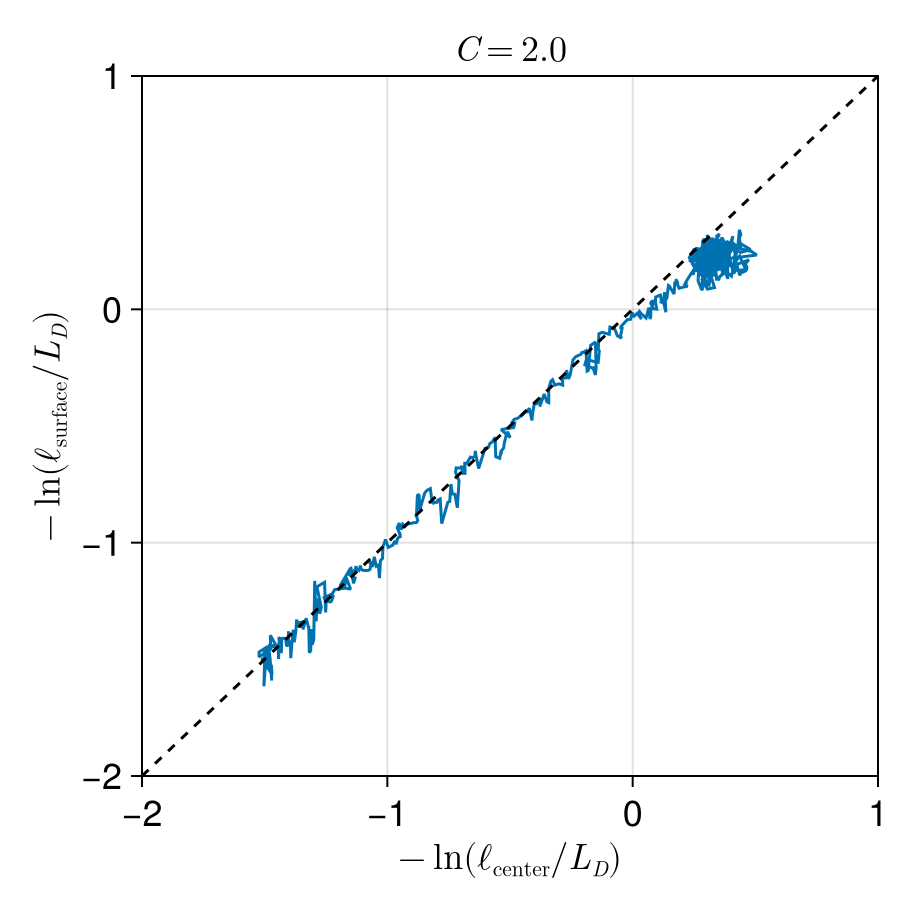

In [45]:
fig = Figure(; size=(455, 455), fontsize=18)
ax = Axis(fig[1, 1];
    xlabel = L"-\ln(\ell_\text{center} / L_D)",
    ylabel = L"-\ln(\ell_\text{surface} / L_D)",
    limits = (-2, 1, -2, 1),
    title = L"C = %$C"
)
ln_surface = lines!(ax, -log.(ℓ_center ./ sp.L), -log.(ℓ_surface ./ sp.L))
ln_surface = lines!(ax, [-2, 1], [-2, 1]; color=:black, linestyle=:dash)

save("center-surface-$C.png", fig; px_per_unit=2)
save("center-surface-$C.svg", fig)
fig

# Frontogenesis: comparisons between simulations

Average square buoyancy gradient with different levels of coarse-graining?
$$
\langle b_{,x}\rangle^2, \langle b_{,z}\rangle^2
$$

In [23]:
foldernames = [
    "../../scratch/turbulence-at-many-fronts/StrainM-Ek07",
    "../../scratch/turbulence-at-many-fronts/StrainM-Ek10",
    "../../scratch/turbulence-at-many-fronts/StrainM-Ek14",
    "../../scratch/turbulence-at-many-fronts/StrainM-Ek20",
]
DFMs = map(foldernames) do foldername 
    joinpath(foldername, "DFM.jld2")
end
RIs = map(foldernames) do foldername 
    joinpath(foldername, "RI.jld2")
end
PVs = map(foldernames) do foldername 
    joinpath(foldername, "PV.jld2")
end
TKEs = map(foldernames) do foldername 
    joinpath(foldername, "TKE.jld2")
end

bx²s = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "M²", iterations) do field
        z1, z2 = zᶜbounds(RI, -90, -10)
        mean(filt(field[inds, z1:z2], 3, 0) .^ 2)
    end
end

bx²s_surface = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "M²", iterations) do field
        z1, z2 = zᶜbounds(RI, -15, -10)
        mean(filt(field[inds, z1:z2], 3, 0) .^ 2)
    end
end

bzs = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "N²", iterations) do field
        z1, z2 = zᶜbounds(RI, -90, -10)
        mean(filt(field[inds, z1:z2], 3, 0))
    end
end

Vqs = map(PVs) do PV
    inds = center_indices(PV)
    iterations, times = iterations_times(PV)
    timeseries_of(PV, "Vq_dfm", iterations) do field
        z1, z2 = zᶜbounds(RI, -90, -10)
        mean(filt(field[inds, z1:z2], 3, 0))
    end
end

qs = map(PVs) do PV
    inds = center_indices(PV)
    iterations, times = iterations_times(PV)
    timeseries_of(PV, "q_dfm", iterations) do field
        z1, z2 = zᶜbounds(RI, -90, -10)
        mean(filt(field[inds, z1:z2], 3, 0))
    end
end

VSPs = map(TKEs) do TKE
    inds = center_indices(TKE)
    iterations, times = iterations_times(TKE)
    timeseries_of(TKE, "VSP", iterations) do field
        z1, z2 = zᶜbounds(RI, -90, -10)
        mean(filt(field[inds, z1:z2], 0, 0))
    end
end

BFLUXs = map(TKEs) do TKE
    inds = center_indices(TKE)
    iterations, times = iterations_times(TKE)
    timeseries_of(TKE, "BFLUX", iterations) do field
        z1, z2 = zᶜbounds(RI, -90, -10)
        mean(filt(field[inds, z1:z2], 3, 0))
    end
end

4-element Vector{Vector{Float64}}:
 [-3.7287327529071674e-12, -1.0662527632482442e-12, -5.900057849847315e-13, -3.3227706292154226e-12, -1.6346609042479238e-12, -1.2778152345047837e-11, -2.6545040236174302e-11, -2.4909468795850107e-11, -2.8125198320532317e-11, -2.789726304577785e-11  …  -2.923486644481077e-11, -2.7377872544241907e-11, -2.1957971974590918e-11, -1.2738682626375505e-11, -4.397040832528676e-12, -3.320432682646018e-11, -1.813451106171919e-11, -1.901103230238447e-11, -2.5450614491355487e-11, -1.489720331549676e-11]
 [-1.2325345681244177e-10, -1.190163717134276e-10, -1.1107911932355924e-10, -1.0181353573102149e-10, -9.731131068818327e-11, -1.0212654137881977e-10, -1.1253950583887542e-10, -1.1275907640590349e-10, -9.146998114108582e-11, -8.458516817140394e-11  …  -8.094728965016357e-11, -7.585094572782136e-11, -3.8358766518760637e-11, -5.7178722572648384e-11, -6.178927234863085e-11, -5.2847505183484504e-11, -9.60108888393774e-11, -6.829859290265058e-11, -5.5010754719756536e-11

In [53]:
bx²s_surface = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "M²", iterations) do field
        z1, z2 = zᶜbounds(RI, -15, -10)
        mean(filt(field, 3, 1)[inds, z1:z2] .^ 2)
    end
end

4-element Vector{Vector{Float64}}:
 [3.1412339717682567e-16, 3.167525354246696e-16, 3.200731706560527e-16, 3.188484126418083e-16, 3.1862369419785415e-16, 3.189904020683096e-16, 3.2130709029577173e-16, 3.2215490006326346e-16, 3.2607691531925687e-16, 3.335498452996373e-16  …  3.4664044666594973e-14, 3.4216793657080733e-14, 3.423456477757303e-14, 3.419373794187193e-14, 3.421549533983364e-14, 3.467331968095226e-14, 3.4347372023160237e-14, 3.430501670503303e-14, 3.449832427803347e-14, 3.4447579107855e-14]
 [5.003625546671839e-16, 5.036061640276125e-16, 4.919792815689637e-16, 5.142481142186436e-16, 4.84384804455119e-16, 4.773668747712697e-16, 4.716485539553944e-16, 4.755994339062081e-16, 4.799487876637696e-16, 4.869173520669188e-16  …  2.3245482698078557e-14, 2.3132746026677098e-14, 2.3431442757057852e-14, 2.350667173391228e-14, 2.32003757575429e-14, 2.329763377605077e-14, 2.2890474260703425e-14, 2.3576202310331668e-14, 2.287932048462904e-14, 2.2758389001434956e-14]
 [9.350674033234658e-16, 

In [48]:
ℓs = map(DFMs) do DFM
    BT = cumulative_avg_b(DFM)
    b_surface = avg_buoyancy(DFM, -15, -10)
    ilr_surface, xlr_surface, ℓ_surface = front_width(DFM, b_surface .- mean(b_surface; dims=2), bl, br)
    ℓ_surface
end;

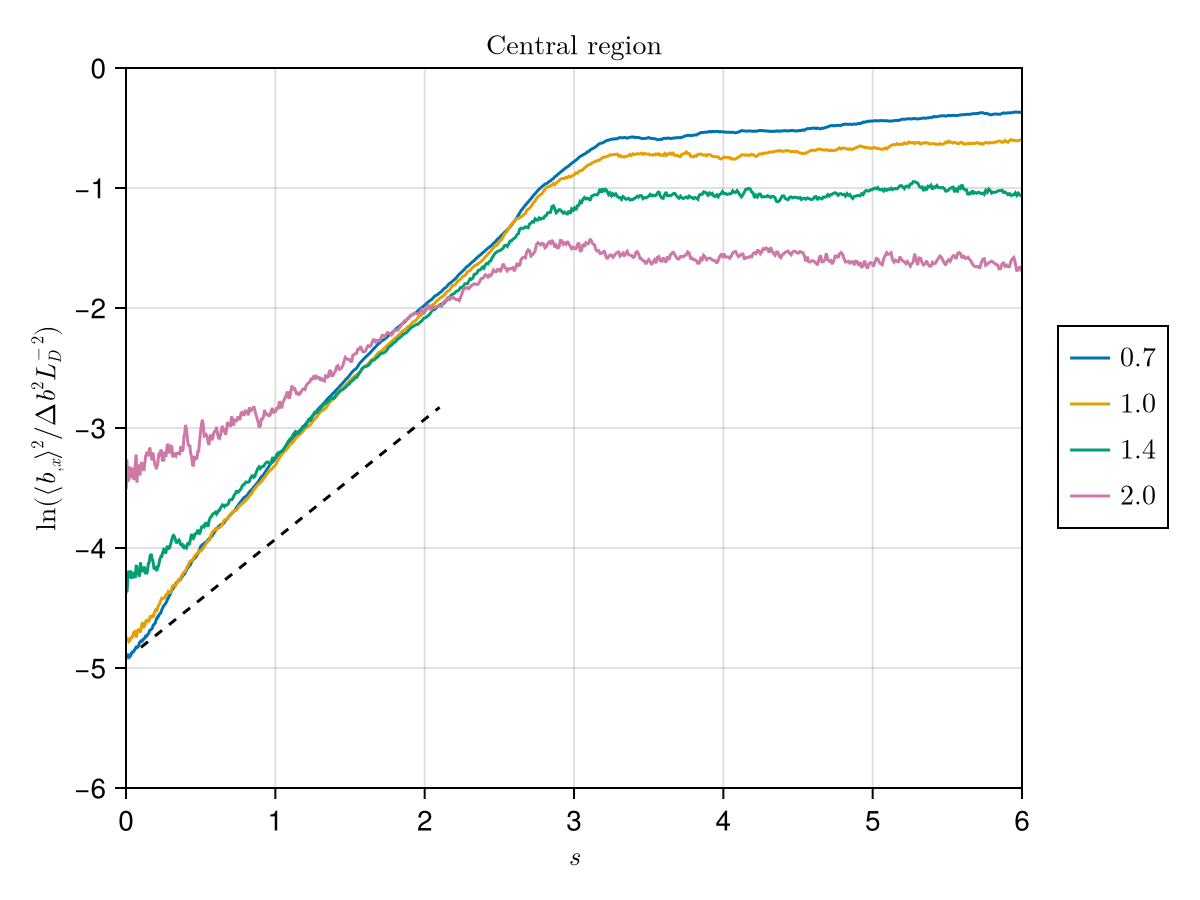

In [31]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\langle b_{,x}\rangle^2 / \Delta b^2 L_D^{-2})",
    limits = (0, 6, -6, 0),
    title = L"\text{Central region}"
)
∫αdt = normalized_time(DFMs[1])

lns = map(bx²s) do bx²
    lines!(ax, ∫αdt, log.(sp.L^2 * bx² / sp.Δb^2))
end

lines!(ax, range(0.1, 2.1, 20), log.(sp.L^2 * bx²s[1][1] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)
#lines!(ax, ∫αdt, 0.2 .+ log.(sp.L^2 * bx²s_passive[1] / sp.Δb^2))

Legend(fig[1, 2], lns, [L"0.7", L"1.0", L"1.4", L"2.0"], label=L"C")

fig

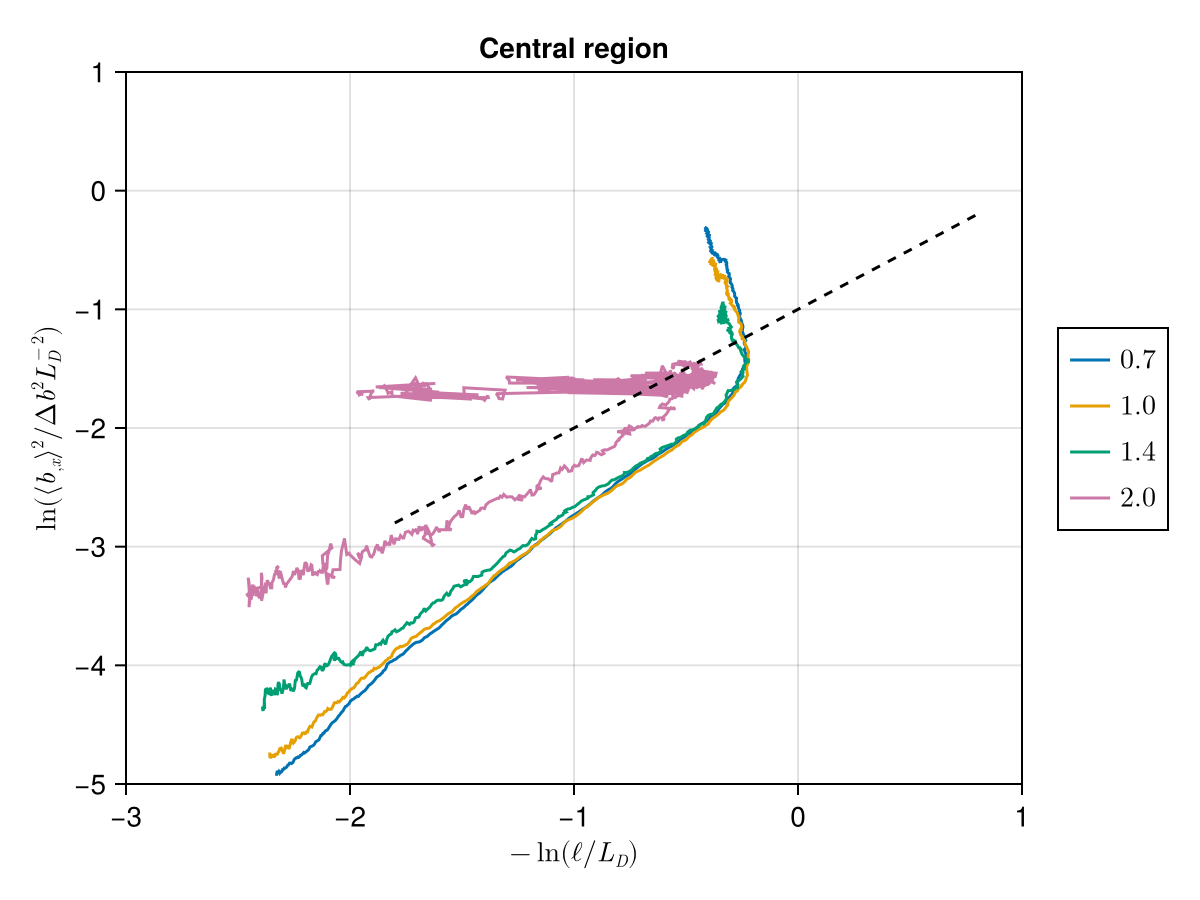

In [28]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"-\ln(\ell / L_D)",
    ylabel = L"\ln(\langle b_{,x}\rangle^2 / \Delta b^2 L_D^{-2})",
    limits = (-3, 1, -5, 1),
    title = "Central region"
)

lns = map(ℓs, bx²s) do ℓ, bx²
    lines!(ax, -log.(ℓ ./ sp.L), log.(sp.L^2 * bx² / sp.Δb^2))
end

lines!(ax, range(-1.8, 0.8, 100), ℓ->ℓ-1; color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"0.7", L"1.0", L"1.4", L"2.0"], label=L"C")

fig

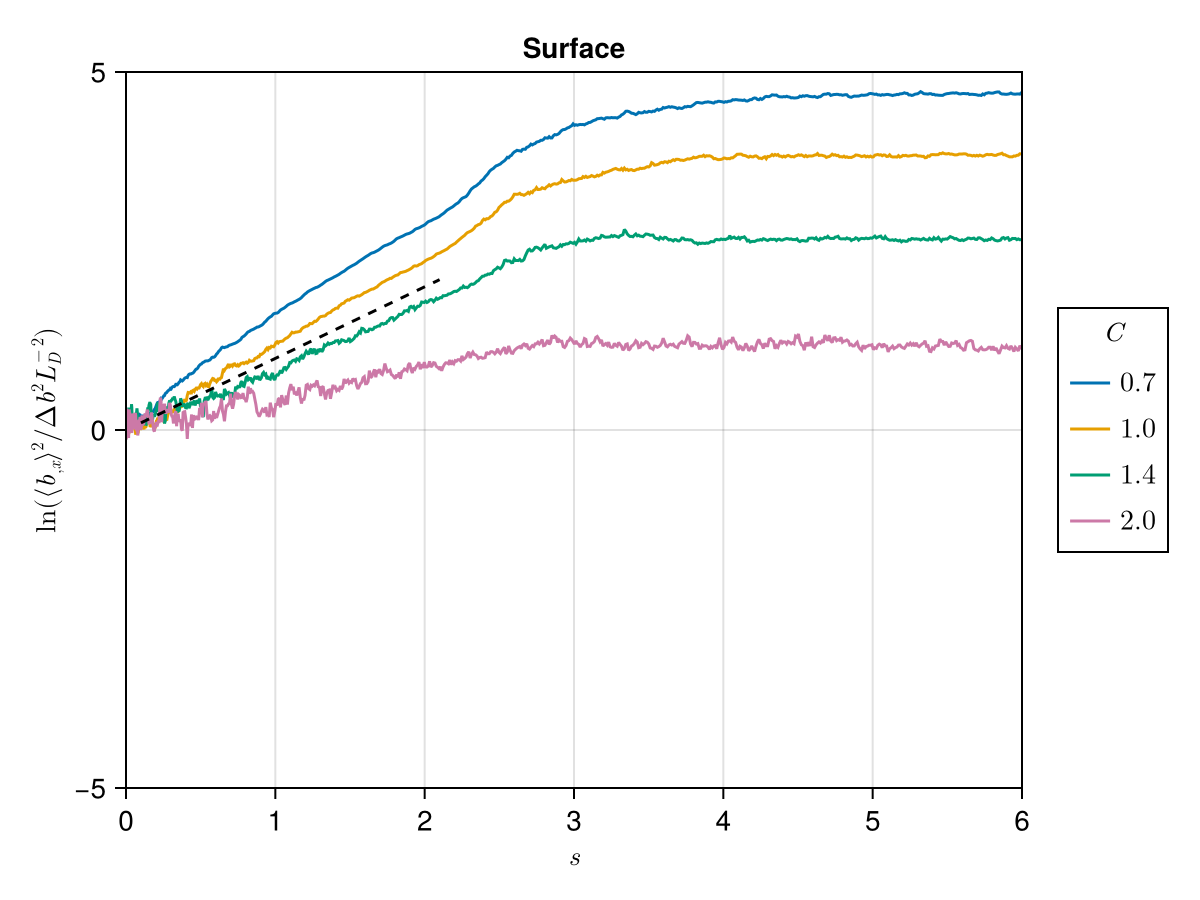

In [59]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\langle b_{,x}\rangle^2 / \Delta b^2 L_D^{-2})",
    limits = (0, 6, -5, 5),
    title = "Surface"
)

lns = map(bx²s_surface) do bx²
    lines!(ax, ∫αdt, log.(bx² ./ bx²[1]))
end
#lines!(ax, ∫αdt, 0.2 .+ log.(sp.L^2 * bx²s_surface_passive[3] / sp.Δb^2); color=:black, linestyle=:dash)
lines!(ax, range(0.1, 2.1, 20), range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"0.7", L"1.0", L"1.4", L"2.0"], L"C")

fig

In [33]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\langle b_{,z}\rangle / \Delta b H^{-1})",
    limits = (0, 6, nothing, nothing),
    title = "Central region"
)

lns = map(bzs) do bz
    lines!(ax, ∫αdt, log.(sp.H * bz / sp.Δb))
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

LoadError: DomainError with -0.00012432874010855904:
log was called with a negative real argument but will only return a complex result if called with a complex argument. Try log(Complex(x)).

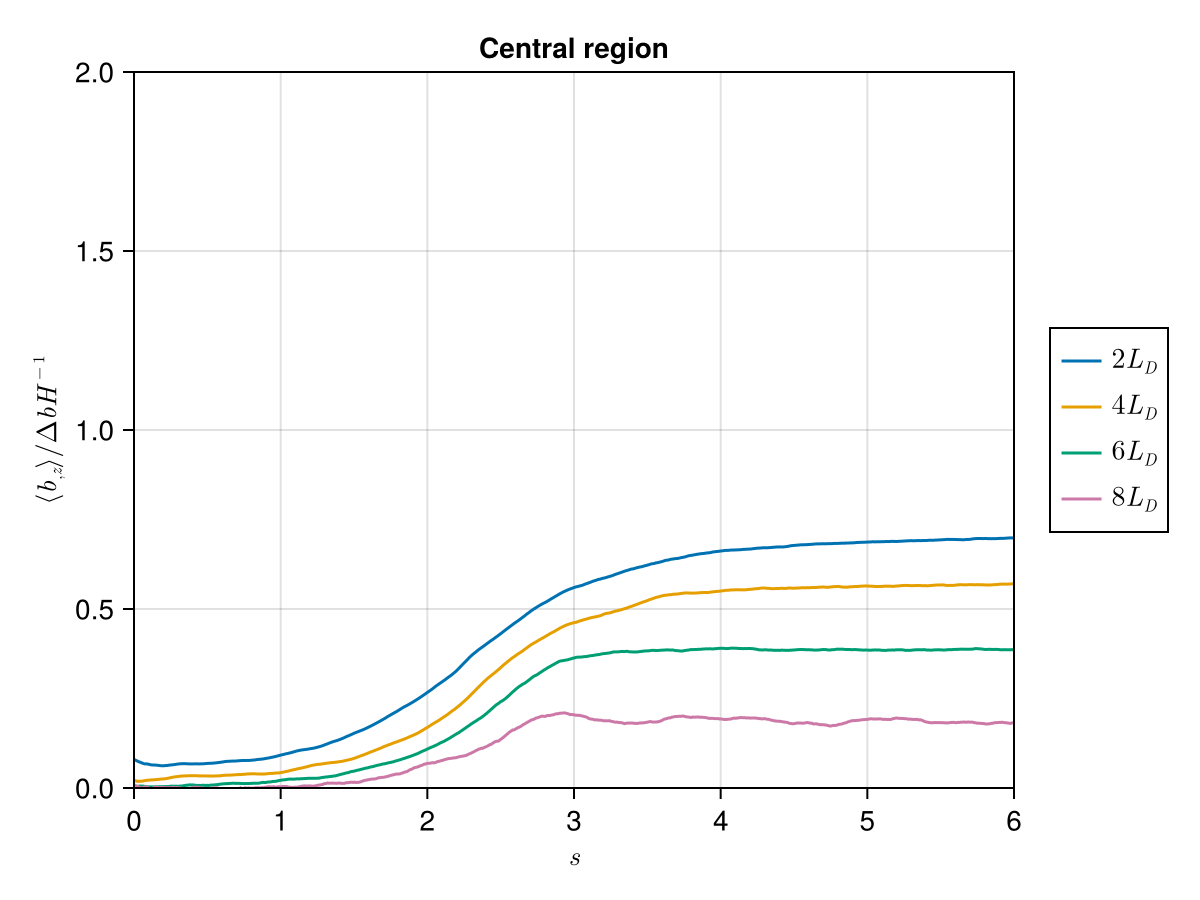

In [35]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\langle b_{,z}\rangle / \Delta b H^{-1}",
    limits = (0, 6, 0, 2),
    title = "Central region"
)

lns = map(bzs) do bz
    lines!(ax, ∫αdt, sp.H * bz / sp.Δb)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

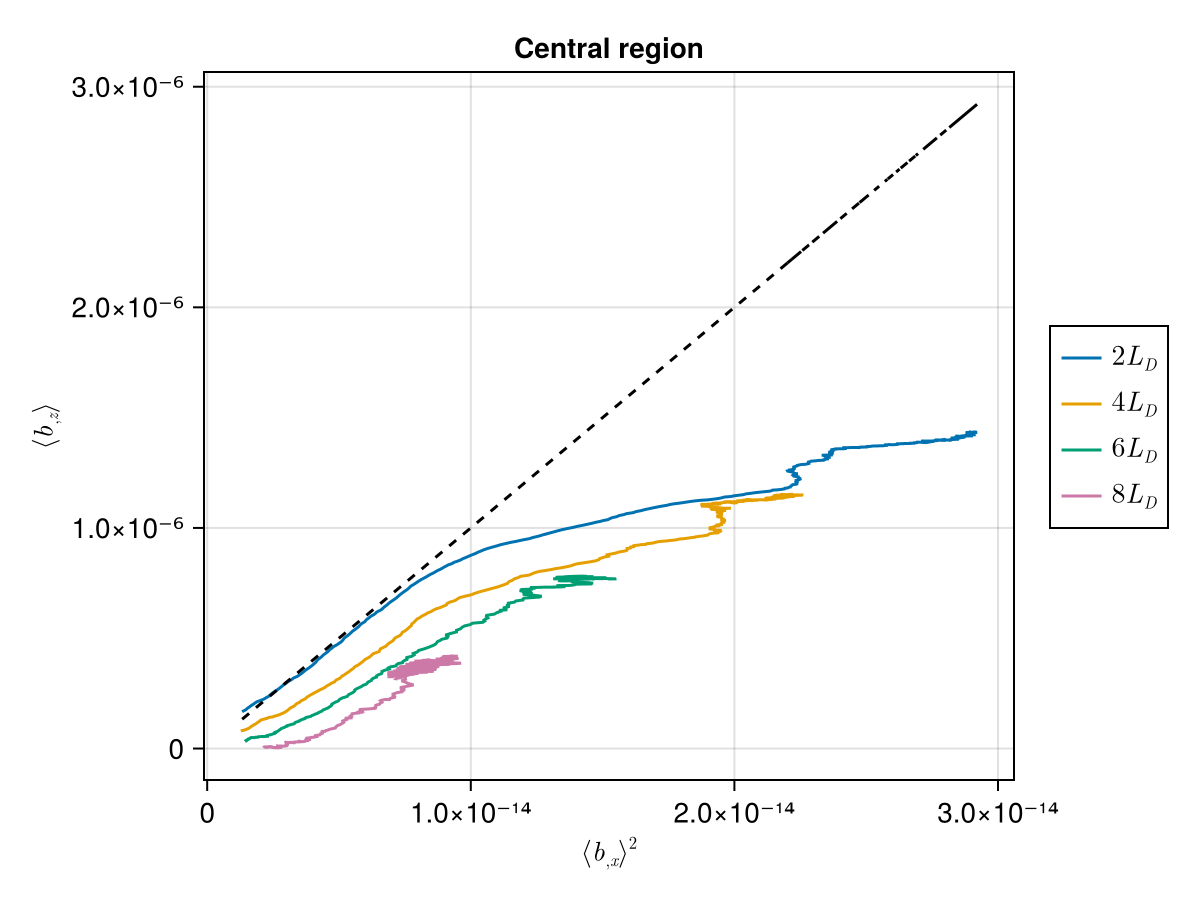

In [36]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"\langle b_{,x}\rangle^2",
    ylabel = L"\langle b_{,z}\rangle",
    limits = (nothing, nothing, nothing, nothing),
    title = "Central region"
)

lns = map(bx²s, bzs) do bx², bz
    lines!(ax, bx²[201:end], bz[201:end])
end
lines!(ax, bx²s[1][201:end], bx²->bx² / sp.f^2; color=:black, linestyle=:dash)
Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

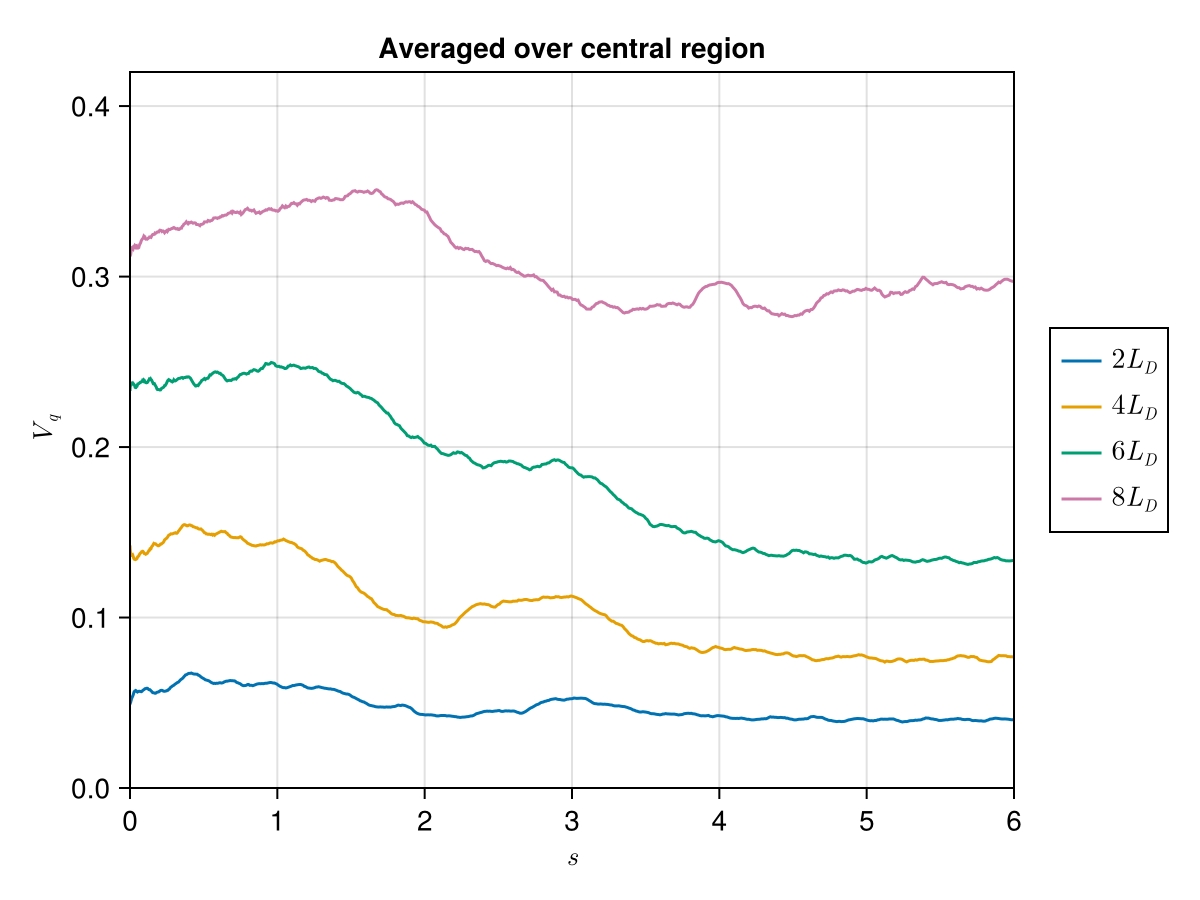

In [38]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"V_q",
    limits = (0, 6, 0, 0.42),
    title = "Averaged over central region"
)

lns = map(Vqs) do Vq
    lines!(ax, ∫αdt, Vq)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

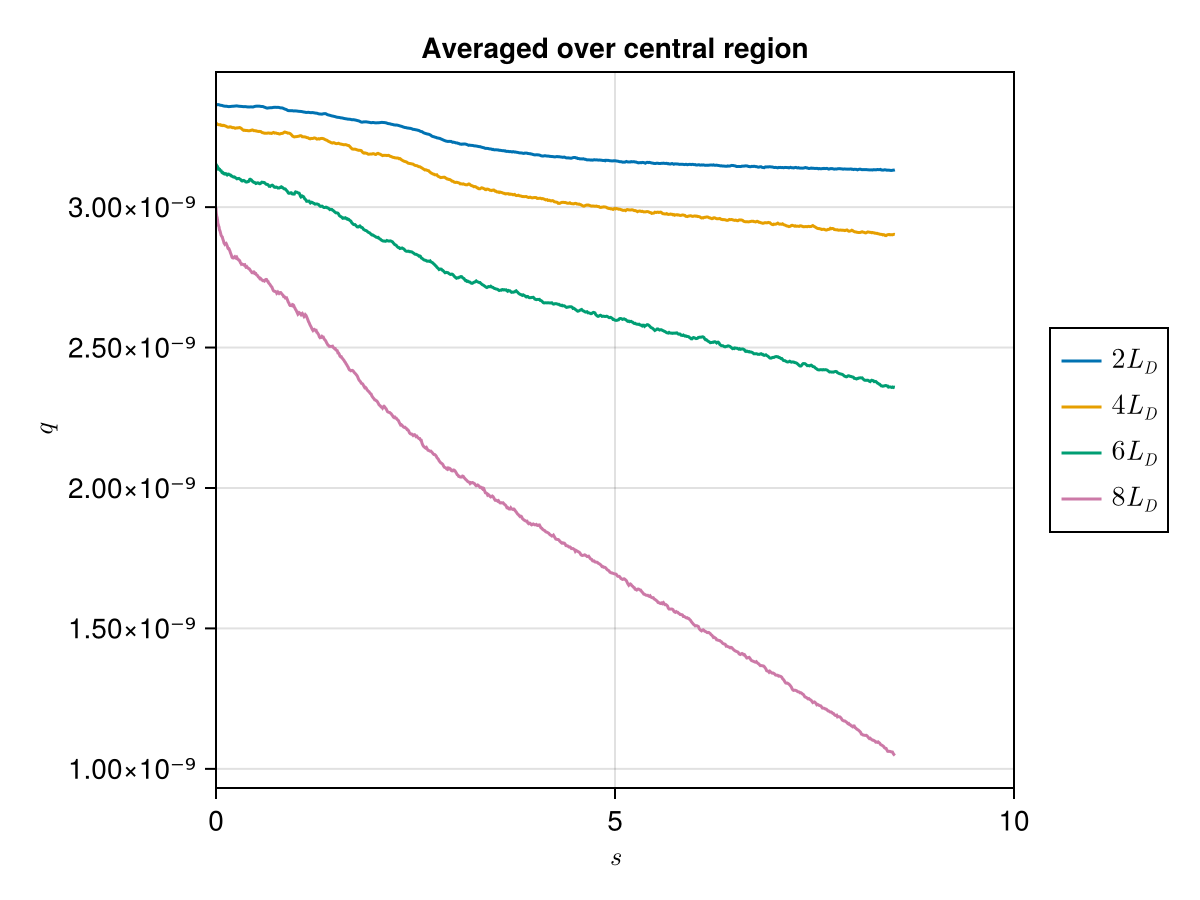

In [41]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"q",
    limits = (0, 10, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(qs) do q
    lines!(ax, ∫αdt, q)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

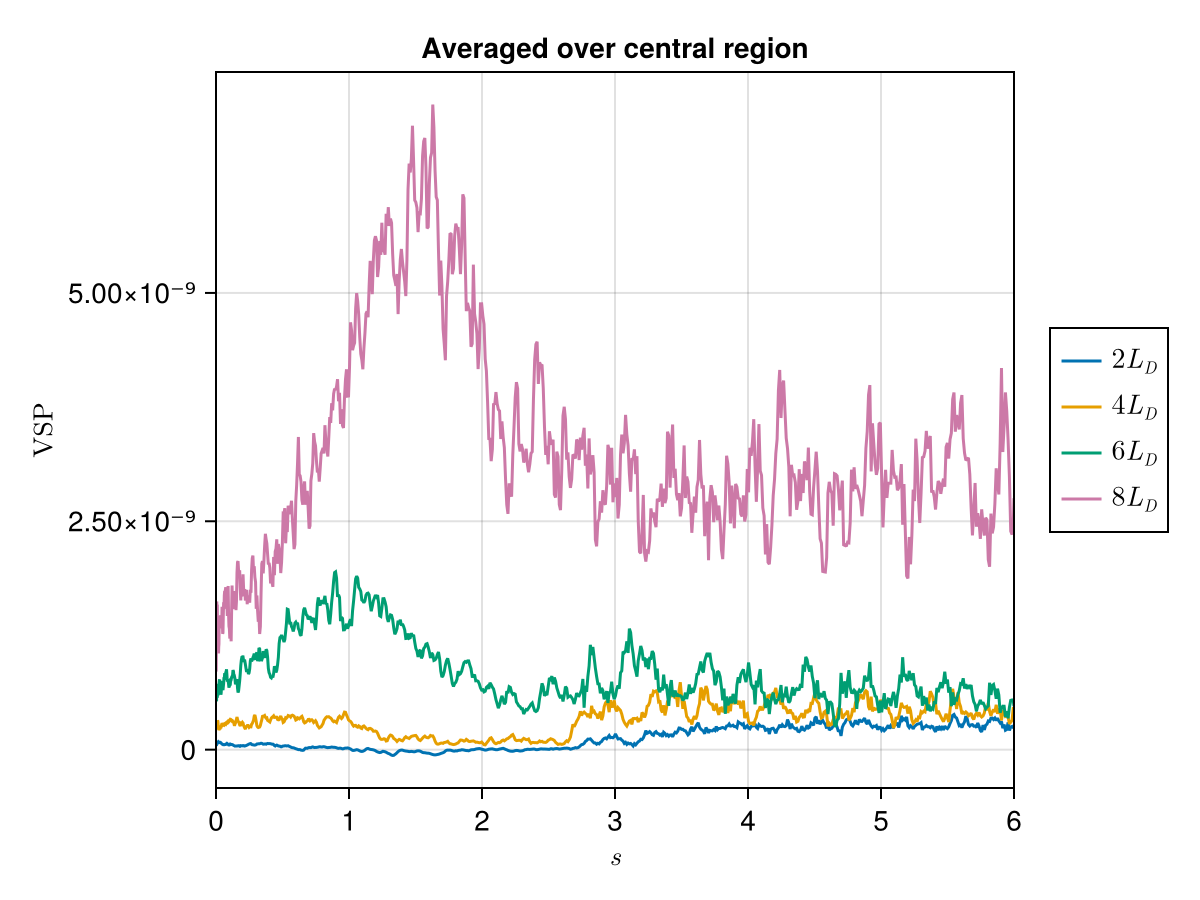

In [42]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\text{VSP}",
    limits = (0, 6, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(VSPs) do VSP
    lines!(ax, ∫αdt, VSP)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

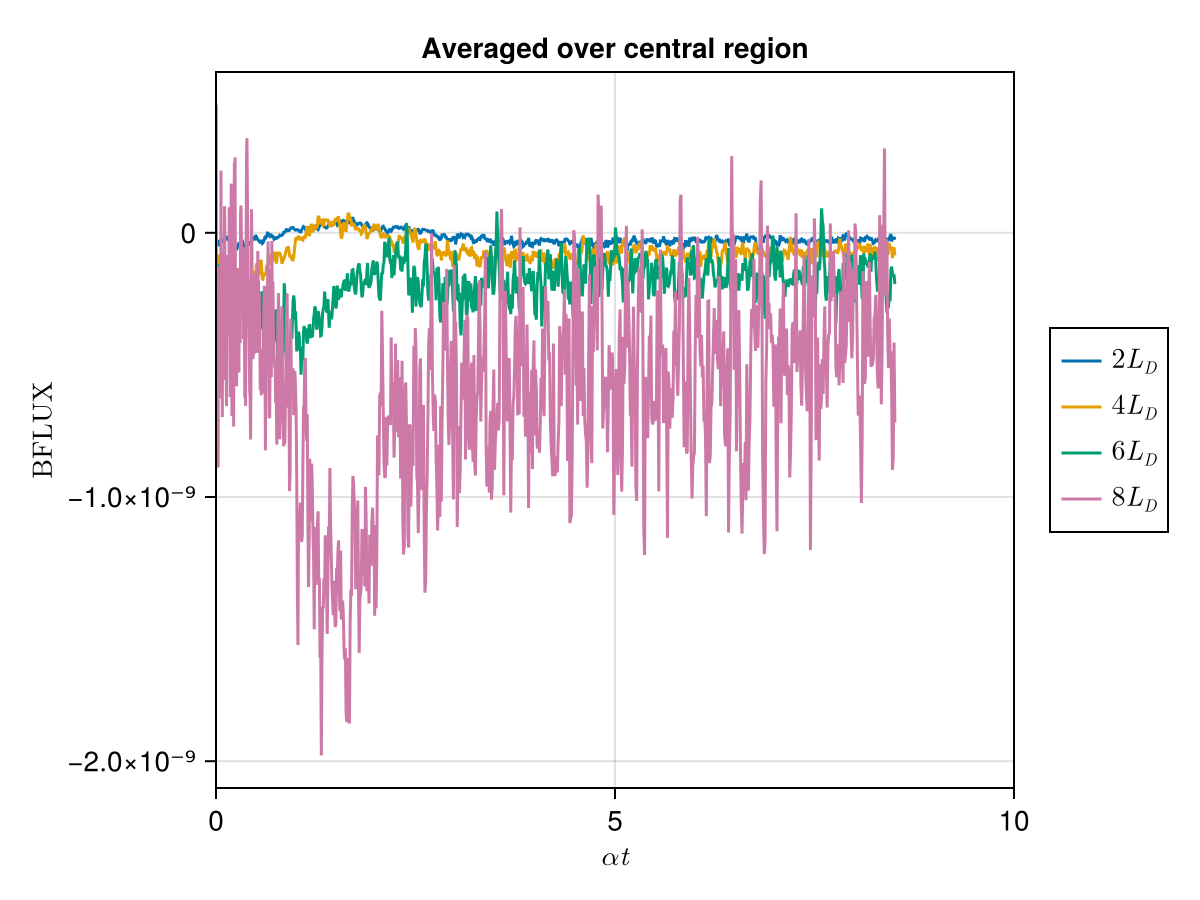

In [45]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"\alpha t",
    ylabel = L"\text{BFLUX}",
    limits = (0, 10, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(BFLUXs) do BFLUX
    lines!(ax, ∫αdt, BFLUX)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

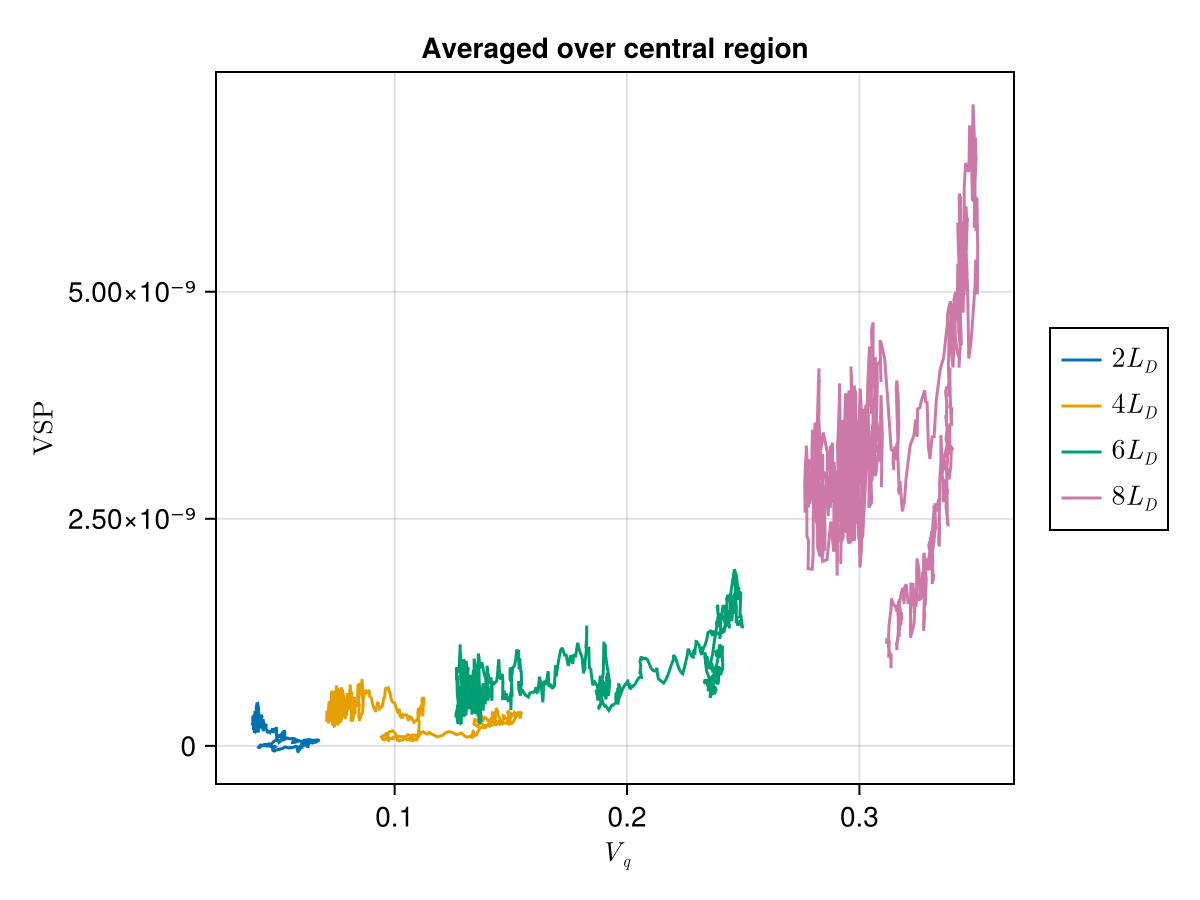

In [46]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"V_q",
    ylabel = L"\text{VSP}",
    limits = (nothing, nothing, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(Vqs, VSPs) do Vq, VSP
    lines!(ax, Vq, VSP)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig